In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/biomedical-nlp-project-beta')

Mounted at /content/drive


# Notebook 10 — TextCNN for Drug-Drug Interaction Relation Extraction

## How Does 1D Convolution Work on Text?

In image processing, a 2D convolution slides a small filter over pixels.  
For text we do the same thing but in **one dimension** — sliding the filter along the sequence of word vectors.

Imagine your sentence as a matrix of shape **(seq_len × embed_dim)**:  
each row is a 200-dim word vector, and we stack all rows top-to-bottom.

A **kernel of size k** looks at **k consecutive word vectors at a time** (a window of k words), and produces one number. The kernel slides from position 0 to position `seq_len - k`, producing a feature map of length `seq_len - k + 1`.

```
Sentence:  [DRUG1] [inhibits] [the] [metabolism] [of] [DRUG2]
            row0      row1    row2     row3       row4   row5

kernel_size=2 windows:
  window 0: [DRUG1,    inhibits]   → score_0
  window 1: [inhibits, the]        → score_1
  window 2: [the,      metabolism] → score_2
  ...and so on
```

## What Do Different Kernel Sizes Capture?

| Kernel size | What it sees | What it learns |
|-------------|-------------|----------------|
| **k = 2** | pairs of adjacent words (bigrams) | "inhibits the", "of DRUG2" |
| **k = 3** | triplets of words (trigrams) | "inhibits the metabolism" |
| **k = 4** | 4-grams | longer interaction phrases |

Using **multiple kernel sizes in parallel** lets the CNN capture short and longer phrases simultaneously, then **max-pooling** picks the single most informative n-gram feature from each filter.

## CNN vs RNN — Key Trade-offs

| | TextCNN | BiLSTM |
|-|---------|--------|
| **Speed** | Fast — all convolutions run in parallel | Slower — must process tokens left-to-right |
| **What it captures** | Local n-gram patterns | Long-range dependencies |
| **Memory** | Low | Higher (hidden states for every token) |
| **Good for** | Short phrases that signal relation type | Sentences where context spans the whole sentence |
| **Interpretability** | Hard (which filter fired?) | Easier with attention |

For DDI, many interaction cues are **short phrases** ("inhibits metabolism", "avoid combination"), which is exactly where CNNs shine.

In [2]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gensim'], check=True)
print('Dependencies ready.')

Dependencies ready.


In [ ]:
# ── Core libraries ────────────────────────────────────────────────────────────
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Word2Vec KeyedVectors
from gensim.models import KeyedVectors

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE        = '/content/drive/MyDrive/biomedical-nlp-project-beta'
DATA_DIR    = os.path.join(BASE, 'data')
MODELS_DIR  = os.path.join(BASE, 'models')
RESULTS_DIR = os.path.join(BASE, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Setup done.')

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_5053/753211157.py", line 21, in <cell line: 0>
    from gensim.models import KeyedVectors
  File "/usr/local/lib/python3.12/dist-packages/gensim/__init__.py", line 11, in <module>
    from gensim import parsing, corpora, matutils, interfaces, models, similarities, utils  # noqa:F401
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gensim/parsing/__init__.py", line 4, in <module>
    from .preprocessing import (  # noqa:F401
  File "/usr/local/lib/python3.12/dist-packages/gensim/parsing/preprocessing.py", line 26, in <module>
    from gensim import utils
  File "/usr/local/lib/python3.12/dist-packages/gensim/utils.py", line 36, in <module>
    from smart_open import open
  File "/usr/

## 1. Load DDI Data and Word2Vec

Identical setup to notebook 09 — same CSVs, same column detection, same preprocessing.

In [ ]:
# ── Load CSVs ─────────────────────────────────────────────────────────────────
train_df = pd.read_csv(os.path.join(DATA_DIR, 'ddi_train.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'ddi_test.csv'))

print('Columns:', train_df.columns.tolist())
print(f'Train: {len(train_df)}  |  Test: {len(test_df)}')
display(train_df.head(3))

In [ ]:
# ── Auto-detect column names ──────────────────────────────────────────────────
def find_col(df, candidates):
    """Return the first matching column name from candidates (case-insensitive)."""
    lower_map = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

SENT_COL  = find_col(train_df, ['sentence', 'text', 'sent'])
E1_COL    = find_col(train_df, ['entity1', 'drug1', 'e1', 'drug_1'])
E2_COL    = find_col(train_df, ['entity2', 'drug2', 'e2', 'drug_2'])
LABEL_COL = find_col(train_df, ['label', 'relation', 'ddi_type', 'type'])

print(f'Sentence: {SENT_COL} | Entity1: {E1_COL} | Entity2: {E2_COL} | Label: {LABEL_COL}')

# Drop rows with missing values in key columns
key_cols = [c for c in [SENT_COL, E1_COL, E2_COL, LABEL_COL] if c]
train_df.dropna(subset=key_cols, inplace=True)
test_df.dropna(subset=key_cols,  inplace=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True,  inplace=True)

In [ ]:
# ── Load Word2Vec KeyedVectors and word2idx ───────────────────────────────────
kv = KeyedVectors.load(os.path.join(MODELS_DIR, 'word2vec_biomedical.kv'))
print(f'KeyedVectors vocab size : {len(kv)}')
print(f'Embedding dimension     : {kv.vector_size}')

with open(os.path.join(MODELS_DIR, 'word2idx.json')) as f:
    word2idx = json.load(f)

EMBED_DIM = kv.vector_size   # 200
PAD_IDX   = 0                # padding token → always all-zeros
UNK_IDX   = 1                # unknown word
print(f'word2idx loaded — {len(word2idx)} entries')

## 2. Data Preparation

Same as notebook 09:
- Replace drug names with `DRUG1` / `DRUG2` (entity blinding)
- Add `DRUG1`, `DRUG2` to vocab with random embeddings
- Tokenize → convert to indices → pad to 150

In [ ]:
# ── Extend vocab with DRUG1 / DRUG2 special tokens ───────────────────────────
SPECIAL_TOKENS = ['DRUG1', 'DRUG2']
for tok in SPECIAL_TOKENS:
    if tok not in word2idx:
        word2idx[tok] = len(word2idx)   # add at the end

VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size after adding DRUG1/DRUG2: {VOCAB_SIZE}')

# Build embedding matrix — row i = vector for word with index i
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)

loaded, random_init = 0, 0
for word, idx in word2idx.items():
    if idx == PAD_IDX:
        pass                               # PAD stays all-zeros
    elif word in kv:
        embedding_matrix[idx] = kv[word]  # copy pre-trained vector
        loaded += 1
    else:
        embedding_matrix[idx] = np.random.uniform(-0.1, 0.1, EMBED_DIM)  # random init
        random_init += 1

print(f'Loaded from Word2Vec: {loaded}  |  Random init: {random_init}')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

In [ ]:
# ── Helper functions (same as notebook 09) ────────────────────────────────────
def tokenize(text):
    """Lowercase and split on whitespace or punctuation."""
    tokens = re.findall(r"[a-z0-9]+(?:['-][a-z0-9]+)*|[^\w\s]", text.lower())
    return tokens if tokens else text.lower().split()


def replace_entities(sentence, e1, e2):
    """Replace entity names with DRUG1 / DRUG2 (case-insensitive, first occurrence)."""
    sent = re.sub(re.escape(str(e1)), 'DRUG1', sentence, count=1, flags=re.IGNORECASE)
    sent = re.sub(re.escape(str(e2)), 'DRUG2', sent,     count=1, flags=re.IGNORECASE)
    return sent


MAX_LENGTH = 150   # pad / truncate all sequences to this length

def encode(sentence, e1, e2):
    """Replace entities → tokenize → index lookup → pad to MAX_LENGTH."""
    sent = replace_entities(str(sentence), str(e1), str(e2))
    toks = tokenize(sent)[:MAX_LENGTH]
    idxs = [word2idx.get(t, UNK_IDX) for t in toks]
    idxs += [PAD_IDX] * (MAX_LENGTH - len(idxs))   # right-pad
    return np.array(idxs, dtype=np.int64)


# Quick sanity check
ex = train_df.iloc[0]
print('Original :', ex[SENT_COL])
print('Replaced :', replace_entities(ex[SENT_COL], ex[E1_COL], ex[E2_COL]))

In [ ]:
# ── Encode all splits ─────────────────────────────────────────────────────────
print('Encoding sentences...')
X_train_all = np.stack([
    encode(train_df[SENT_COL].iloc[i], train_df[E1_COL].iloc[i], train_df[E2_COL].iloc[i])
    for i in range(len(train_df))
])
X_test = np.stack([
    encode(test_df[SENT_COL].iloc[i], test_df[E1_COL].iloc[i], test_df[E2_COL].iloc[i])
    for i in range(len(test_df))
])
print(f'X_train_all: {X_train_all.shape} | X_test: {X_test.shape}')

In [ ]:
# ── Label encoding — print exact mapping ─────────────────────────────────────
le = LabelEncoder()
all_labels = pd.concat([train_df[LABEL_COL], test_df[LABEL_COL]]).unique()
le.fit(sorted(all_labels))

label2id    = {lbl: idx for idx, lbl in enumerate(le.classes_)}
id2label    = {idx: lbl for lbl, idx in label2id.items()}
NUM_CLASSES = len(le.classes_)
CLASS_NAMES = le.classes_.tolist()

print('Relation label → integer mapping:')
for lbl, idx in sorted(label2id.items(), key=lambda x: x[1]):
    count = (train_df[LABEL_COL] == lbl).sum()
    print(f'  {idx}  →  "{lbl}"  (train count: {count})')

y_train_all = le.transform(train_df[LABEL_COL].values)
y_test      = le.transform(test_df[LABEL_COL].values)

In [ ]:
# ── 80/20 stratified train / validation split ─────────────────────────────────
# stratify=y keeps the same class ratio in both train and val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_all
)
print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

In [ ]:
# ── PyTorch Dataset + DataLoader ──────────────────────────────────────────────
class DDIDataset(Dataset):
    """Wraps (X, y) arrays for PyTorch."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):             return len(self.X)
    def __getitem__(self, idx):    return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_loader = DataLoader(DDIDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(DDIDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(DDIDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f'Batches — Train: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

## 3. Class Weights

Same imbalance problem as notebook 09 (~70 % `no-relation`).  
Same fix: inverse-frequency weights with square-root smoothing.

In [ ]:
# ── Compute sqrt-smoothed inverse-frequency class weights ────────────────────
counts   = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
raw_w    = len(y_train) / (NUM_CLASSES * counts)   # inverse-frequency
smooth_w = np.sqrt(raw_w)                           # sqrt smoothing prevents extremes

class_weights = torch.tensor(smooth_w, dtype=torch.float32).to(DEVICE)

print('Class weights (after sqrt smoothing):')
for i, lbl in enumerate(CLASS_NAMES):
    print(f'  {lbl:15s}  count={int(counts[i]):6d}  weight={smooth_w[i]:.3f}')

## 4. TextCNN Model

### Architecture Overview
```
Input (batch, 150)  → token indices
    ↓ Embedding (vocab_size → 200)
(batch, 150, 200)
    ↓ permute → (batch, 200, 150)   ← Conv1d expects (batch, channels, length)
    ↓ Three parallel Conv1d branches:
       conv2: kernel=2 → ReLU → AdaptiveMaxPool1d(1) → (batch, 100, 1)
       conv3: kernel=3 → ReLU → AdaptiveMaxPool1d(1) → (batch, 100, 1)
       conv4: kernel=4 → ReLU → AdaptiveMaxPool1d(1) → (batch, 100, 1)
    ↓ Squeeze + Concatenate → (batch, 300)
    ↓ Dropout(0.5) → Linear(300→128) → ReLU → Linear(128→num_classes)
(batch, num_classes) → logits
```

### Why AdaptiveMaxPool1d(1)?
After a kernel-2 conv on a length-150 sequence you get a feature map of length 149.  
After kernel-3 you get 148, after kernel-4 you get 147 — all different lengths.  
`AdaptiveMaxPool1d(1)` collapses **any** length to exactly 1 value by taking the max,  
so all three branches produce the same size and can be concatenated.

In [ ]:
class TextCNN_RE(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, embedding_matrix):
        super().__init__()

        # ── Embedding ────────────────────────────────────────────────────────
        # padding_idx=0 → PAD token never gets updated
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = True   # fine-tune during training

        # ── Three parallel 1D convolution branches ────────────────────────────
        # in_channels = embed_dim (200) — one "channel" per embedding dimension
        # out_channels = 100            — number of filters (features) to learn
        # kernel_size  = k              — how many consecutive words each filter sees
        self.conv2 = nn.Conv1d(in_channels=embed_dim, out_channels=100, kernel_size=2)
        self.conv3 = nn.Conv1d(in_channels=embed_dim, out_channels=100, kernel_size=3)
        self.conv4 = nn.Conv1d(in_channels=embed_dim, out_channels=100, kernel_size=4)

        # AdaptiveMaxPool1d(1) → shrinks any-length feature map to a single number
        # (picks the maximum activation across all positions → "best matching n-gram")
        self.pool = nn.AdaptiveMaxPool1d(output_size=1)

        # ── Classifier head ──────────────────────────────────────────────────
        # After concat: 3 branches × 100 filters = 300 features
        self.dropout = nn.Dropout(0.5)
        self.fc1     = nn.Linear(300, 128)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(128, num_classes)


    def forward(self, x):
        """
        x: (batch, seq_len)  — token indices
        """
        # Step 1: embed tokens
        # (batch, seq_len) → (batch, seq_len, embed_dim)
        emb = self.embedding(x)

        # Step 2: permute for Conv1d
        # Conv1d expects (batch, in_channels, length)
        # so we swap the last two dims: (batch, seq_len, 200) → (batch, 200, seq_len)
        emb = emb.permute(0, 2, 1)   # (batch, 200, 150)

        # Step 3: convolution + ReLU + max-pool for each kernel size
        # conv(emb)  → (batch, 100, seq_len - k + 1)
        # pool(...)  → (batch, 100, 1)
        # squeeze(-1)→ (batch, 100)
        out2 = self.pool(torch.relu(self.conv2(emb))).squeeze(-1)  # bigrams
        out3 = self.pool(torch.relu(self.conv3(emb))).squeeze(-1)  # trigrams
        out4 = self.pool(torch.relu(self.conv4(emb))).squeeze(-1)  # 4-grams

        # Step 4: concatenate all three branches
        # (batch, 100) × 3 → (batch, 300)
        combined = torch.cat([out2, out3, out4], dim=1)

        # Step 5: classify
        out = self.dropout(combined)
        out = self.relu(self.fc1(out))
        logits = self.fc2(out)          # (batch, num_classes)
        return logits


# ── Instantiate ───────────────────────────────────────────────────────────────
model = TextCNN_RE(
    vocab_size       = VOCAB_SIZE,
    embed_dim        = EMBED_DIM,
    num_classes      = NUM_CLASSES,
    embedding_matrix = embedding_matrix
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

## 5. Training

Same setup as notebook 09:
- **Adam** lr=1e-3
- **Weighted CrossEntropyLoss** (rare classes penalised more)
- **ReduceLROnPlateau** — halves LR if val macro-F1 stalls for 2 epochs
- **Early stopping** — stops if val macro-F1 doesn't improve for 5 epochs

In [ ]:
# ── Loss and optimiser ────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Halve the learning rate if val macro-F1 doesn't improve for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

# ── Training loop ─────────────────────────────────────────────────────────────
NUM_EPOCHS     = 20
EARLY_STOP_PAT = 5
SAVE_PATH      = os.path.join(MODELS_DIR, 'cnn_re.pt')

best_val_f1    = 0.0
patience_count = 0
train_losses, val_f1s = [], []


def run_epoch(loader, train=True):
    """One full pass. Returns (avg_loss, macro_f1)."""
    model.train(train)   # enable/disable dropout
    total_loss, all_preds, all_labels = 0.0, [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        if train:
            optimizer.zero_grad()

        logits = model(X_batch)
        loss   = criterion(logits, y_batch)

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1


print(f'Training for up to {NUM_EPOCHS} epochs (early stopping patience={EARLY_STOP_PAT})\n')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_f1 = run_epoch(train_loader, train=True)
    with torch.no_grad():
        val_loss, val_f1 = run_epoch(val_loader, train=False)

    scheduler.step(val_f1)
    train_losses.append(tr_loss)
    val_f1s.append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        torch.save(model.state_dict(), SAVE_PATH)
        marker = ' ← best'
    else:
        patience_count += 1
        marker = f' (patience {patience_count}/{EARLY_STOP_PAT})'

    print(f'Epoch {epoch:2d} | train_loss={tr_loss:.4f}  train_f1={tr_f1:.4f}  '
          f'val_f1={val_f1:.4f}{marker}')

    if patience_count >= EARLY_STOP_PAT:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

print(f'\nBest val macro-F1: {best_val_f1:.4f}  →  saved to {SAVE_PATH}')

In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].legend()

axes[1].plot(val_f1s, label='Val Macro-F1', color='darkorange')
axes[1].axhline(best_val_f1, linestyle='--', color='grey', alpha=0.6,
                label=f'Best = {best_val_f1:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].set_title('Validation Macro-F1'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '10_cnn_re_loss.png'), dpi=150)
plt.show()

## 6. Evaluation on Test Set

In [ ]:
# Load the best saved checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(DEVICE))
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.numpy())

macro_f1    = f1_score(all_true, all_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(all_true, all_preds, average='weighted', zero_division=0)

print('=' * 55)
print(f'Test macro-F1    : {macro_f1:.4f}')
print(f'Test weighted-F1 : {weighted_f1:.4f}')
print('=' * 55)
print()
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, zero_division=0))

In [ ]:
# ── Normalised confusion matrix ───────────────────────────────────────────────
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Oranges',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('TextCNN — Normalised Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '10_cnn_confusion.png'), dpi=150)
plt.show()

## 7. Model Comparison

Now we compare all three approaches we have tried so far on DDI relation extraction.

In [ ]:
# ── Load previously saved results ─────────────────────────────────────────────
# re_results.json may be a dict (classical_re key) or a list (notebook 09 format)
results_path = os.path.join(RESULTS_DIR, 're_results.json')

saved_results = {}   # method_name → {'macro_f1': ..., 'weighted_f1': ...}

if os.path.exists(results_path):
    with open(results_path) as f:
        raw = json.load(f)

    if isinstance(raw, dict):
        # Original format: keys are method names
        for method, data in raw.items():
            saved_results[method] = data
    elif isinstance(raw, list):
        # Notebook-09 format: list of dicts with a 'method' key
        for entry in raw:
            saved_results[entry.get('method', '?')] = entry

# ── Build comparison rows ─────────────────────────────────────────────────────
# Fallback values come from re_results.json (classical_re entry) which we know
# has macro_f1=0.5765 and weighted_f1=0.8233 from notebook 08.

def get_f1(method, fallback_macro, fallback_weighted):
    """Read from saved_results or return fallback values."""
    if method in saved_results:
        d = saved_results[method]
        return d.get('macro_f1', fallback_macro), d.get('weighted_f1', fallback_weighted)
    return fallback_macro, fallback_weighted


m1, w1 = get_f1('classical_re',    0.5765, 0.8233)   # LogReg from notebook 08
m2, w2 = get_f1('bilstm_attention', None,   None)     # BiLSTM+Attn from notebook 09
m3, w3 = macro_f1, weighted_f1                        # TextCNN — just computed

rows = [
    {'Method': 'Classical ML (Logistic Regression)', 'Macro F1': m1,  'Weighted F1': w1},
    {'Method': 'BiLSTM + Self-Attention',             'Macro F1': m2,  'Weighted F1': w2},
    {'Method': 'TextCNN (k=2,3,4)',                   'Macro F1': round(m3, 4), 'Weighted F1': round(w3, 4)},
]

comp_df = pd.DataFrame(rows)

# Format nicely — bold the best score in each column
print('\n── DDI Relation Extraction — Model Comparison ──')
print(comp_df.to_string(index=False))

# ── Bar chart comparison ──────────────────────────────────────────────────────
methods   = comp_df['Method'].tolist()
# Filter out rows where F1 is None (notebook 09 may not have run yet)
valid_macro    = [r for r in rows if r['Macro F1'] is not None]
valid_weighted = [r for r in rows if r['Weighted F1'] is not None]

x     = np.arange(len(rows))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2,
               [r['Macro F1']    if r['Macro F1']    is not None else 0 for r in rows],
               width, label='Macro F1',    color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2,
               [r['Weighted F1'] if r['Weighted F1'] is not None else 0 for r in rows],
               width, label='Weighted F1', color='darkorange', alpha=0.85)

# Annotate bar heights
for bar in bars1 + bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=10, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.0)
ax.set_title('DDI Relation Extraction — Model Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '10_re_model_comparison.png'), dpi=150)
plt.show()

In [ ]:
# ── ROC / AUC Curves (one-vs-rest for each class) ────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get prediction PROBABILITIES (not just argmax)
model.eval()
all_probs, all_true_roc = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(DEVICE))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_true_roc.extend(y_batch.numpy())

all_probs    = np.array(all_probs)     # (n_samples, num_classes)
all_true_roc = np.array(all_true_roc)

# Binarize true labels for one-vs-rest ROC
y_bin = label_binarize(all_true_roc, classes=list(range(NUM_CLASSES)))

# Plot ROC curve for each class
plt.figure(figsize=(9, 6))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — DDI Relation Extraction (One-vs-Rest)', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '09_roc_auc.png'), dpi=150)  # change 09→10 for nb10
plt.show()

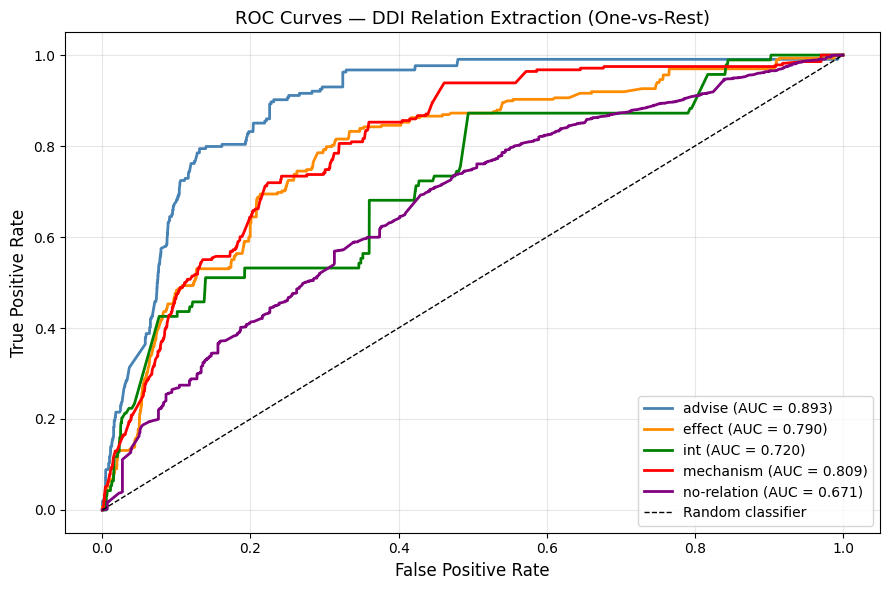

## 8. Save Results

In [ ]:
# ── Per-class F1 ──────────────────────────────────────────────────────────────
per_class_f1 = {
    CLASS_NAMES[i]: round(
        f1_score(all_true, all_preds, labels=[i], average='macro', zero_division=0), 4
    )
    for i in range(NUM_CLASSES)
}

new_result = {
    'method'      : 'textcnn',
    'task'        : 'DDI Relation Extraction',
    'model'       : 'TextCNN (kernel sizes 2, 3, 4)',
    'macro_f1'    : round(macro_f1,    4),
    'weighted_f1' : round(weighted_f1, 4),
    'per_class_f1': per_class_f1,
    'hyperparams' : {
        'num_filters' : 100,
        'kernel_sizes': [2, 3, 4],
        'max_length'  : MAX_LENGTH,
        'batch_size'  : BATCH_SIZE,
        'lr'          : 1e-3,
        'epochs_run'  : len(train_losses),
        'dropout'     : 0.5,
    },
    'num_train': len(X_train),
    'num_test' : len(X_test),
}

# Upsert: load existing list, remove old textcnn entry, append new one
if os.path.exists(results_path):
    with open(results_path) as f:
        try:
            existing = json.load(f)
            if not isinstance(existing, list):
                existing = []
        except json.JSONDecodeError:
            existing = []
else:
    existing = []

existing = [r for r in existing if r.get('method') != 'textcnn']
existing.append(new_result)

with open(results_path, 'w') as f:
    json.dump(existing, f, indent=2)

print('Results saved to re_results.json')
print(f'\nFinal test macro-F1 : {macro_f1:.4f}')
print(f'Final test weighted : {weighted_f1:.4f}')
print('\nPer-class F1:')
for lbl, sc in per_class_f1.items():
    print(f'  {lbl:15s}: {sc:.4f}')

Test macro-F1    : 0.2504
Test weighted-F1 : 0.7462

              precision    recall  f1-score   support

      advise       0.23      0.58      0.33       214
      effect       1.00      0.01      0.01       298
         int       0.00      0.00      0.00        94
   mechanism       0.27      0.01      0.03       278
 no-relation       0.85      0.91      0.88      4381

    accuracy                           0.78      5265
   macro avg       0.47      0.30      0.25      5265
weighted avg       0.78      0.78      0.75      5265

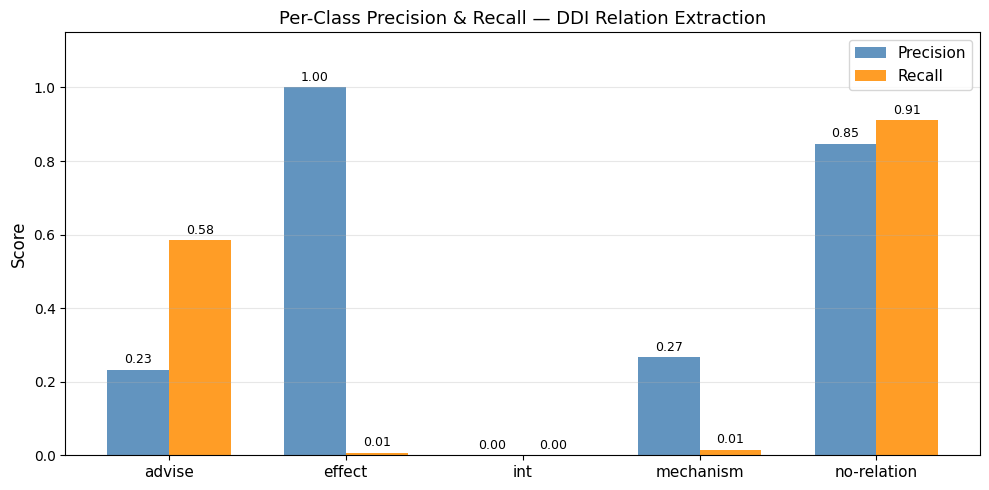

## Summary

| Component | Detail |
|-----------|--------|
| Input | DDI sentence with DRUG1/DRUG2 entity markers |
| Embedding | 200-dim Word2Vec (biomedical), fine-tuned |
| Feature extraction | Three parallel Conv1d (k=2, k=3, k=4), 100 filters each |
| Aggregation | AdaptiveMaxPool1d(1) per branch → concatenate → 300 features |
| Classifier | Dropout(0.5) → Linear(300→128) → ReLU → Linear(128→5) |
| Loss | Weighted CrossEntropyLoss (sqrt-smoothed class weights) |
| Optimiser | Adam lr=1e-3 + ReduceLROnPlateau |

### CNN vs BiLSTM — When Does Each Win?
- **TextCNN** is faster to train (fully parallel) and works well when the key evidence is a **short phrase** near the two drugs.
- **BiLSTM+Attention** can capture dependencies across the whole sentence, so it tends to do better when the interaction cue is **far from the drugs** or requires understanding the full sentence context.
- **Classical ML** (TF-IDF + LogReg) still has competitive weighted-F1 because most sentences belong to `no-relation` which TF-IDF handles well — but it falls short on rare interaction types where neural models with embeddings generalise better.